Shape: (301, 9)
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  
MAE: 0.59
R² Score: 0.9660


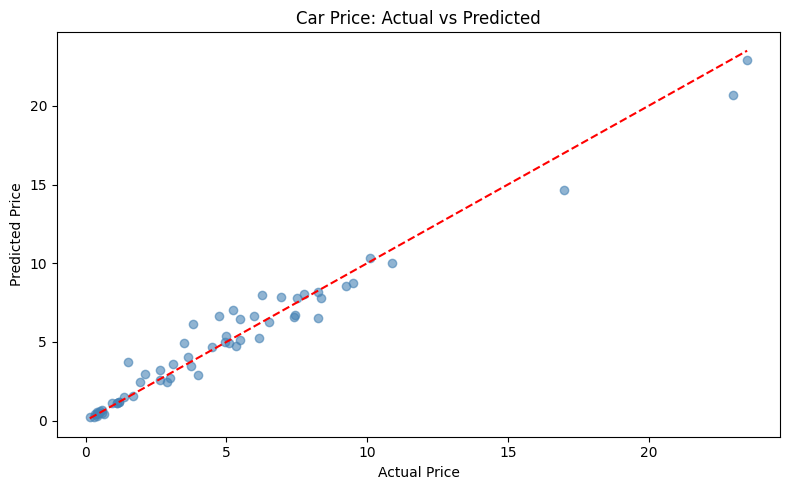

/tmp/ipykernel_935/191615183.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature',


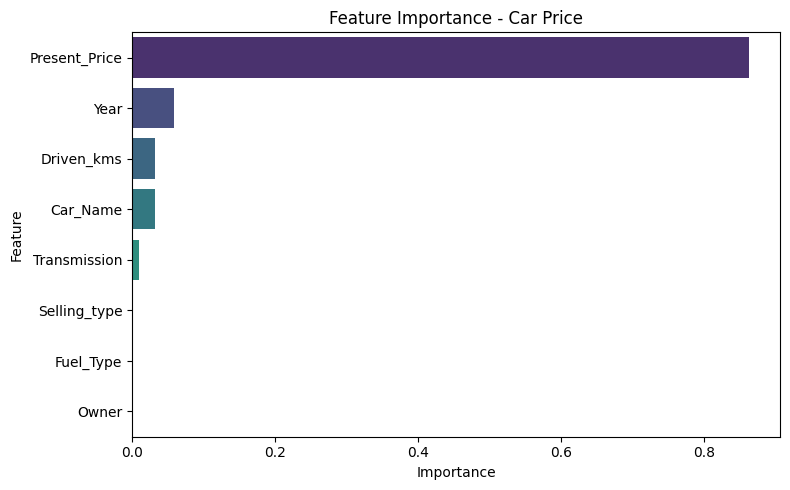

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# 1. Load Dataset
df = pd.read_csv('car data.csv')
print("Shape:", df.shape)
print(df.head())

# 2. Data Cleaning
df.dropna(inplace=True)
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# 3. Feature Selection
X = df.drop(columns=['Selling_Price'])
y = df['Selling_Price']

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 5. Train Model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# 6. Evaluation
print(f"MAE: {mean_absolute_error(y_test, rf_pred):.2f}")
print(f"R² Score: {r2_score(y_test, rf_pred):.4f}")

# 7. Actual vs Predicted Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_pred, alpha=0.6, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Car Price: Actual vs Predicted')
plt.tight_layout()
plt.show()

# 8. Feature Importance
importances = rf.feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns,
                        'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature',
            palette='viridis')
plt.title('Feature Importance - Car Price')
plt.tight_layout()
plt.show()